# Error Analysis — Winogrande

**Benchmark:** Winogrande
**Description:** Pronoun resolution using commonsense; 1-of-2
**Random baseline:** 50%
**Our generator(s) targeting this:** Gen F (Winogrande-style pronoun resolution, GPT-4o)

This notebook drills into why the model isn't getting a higher score. It:
1. Splits every question into `answerable` / `unanswerable` / `ambiguous` using a hybrid keyword + LLM-judge classifier (cached).
2. Reports accuracy stratified by answerability — so we see real model capability, not just raw score.
3. Examines confidence on wrong answers (high-confidence wrong = learned wrong pattern).
4. Surfaces the highest-confidence wrong answers on the *answerable* subset — these are the diagnostic gold.
5. Compares Mid vs SFT phases to see where the gap closed or opened.
6. Delivers a one-line verdict: content gap, skill gap, or both.

In [1]:
import sys
from pathlib import Path

# Ensure project root is importable
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "post_training").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.post_training.analysis import (
    load_details, load_classifications, classify_batch,
    accuracy_triple, confidence_breakdown, high_confidence_wrong,
    plot_confidence_histogram, extract_stem_and_choices,
)
from src.post_training.analysis.answerability import _hash_question

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

BENCHMARK = "Winogrande"
RANDOM_BASELINE = 0.5

BASE = Path(r'D:/hist_LLM/periods/1900_1949/error_analysis_new')
CACHE = BASE / '.answerability_cache' / f'{BENCHMARK}.jsonl'

STAGES = ['mid_final', 'sft_final', 'sft_final_debiased']
dfs = {}
for stage in STAGES:
    p = BASE / stage / f'{BENCHMARK}_details.jsonl'
    dfs[stage] = load_details(p)
    print(f'{stage}: {len(dfs[stage])} rows')

mid_final: 320 rows
sft_final: 320 rows
sft_final_debiased: 320 rows


## 1. Answerability Classifications

Load the cached classifications. If the cache is missing, build it now.
(Classifier is hybrid: keyword filter first, then LLM judge for the ambiguous middle.)

In [2]:
classes = load_classifications(CACHE)
print(f'Cached classifications: {len(classes)}')

if len(classes) < len(dfs['mid_final']):
    print('Cache incomplete — building now...')
    questions = []
    for i, row in dfs['mid_final'].iterrows():
        questions.append({'index': int(row['index']), 'question': row['question']})
    classify_batch(questions, CACHE, start_year=1900, end_year=1949)
    classes = load_classifications(CACHE)
    print(f'Now cached: {len(classes)}')

from collections import Counter
label_counts = Counter(r['label'] for r in classes.values())
print(f'\nLabel distribution: {dict(label_counts)}')

Cached classifications: 320

Label distribution: {'ambiguous': 29, 'answerable': 243, 'unanswerable': 48}


## 2. Accuracy Stratified by Answerability

The headline question: **on the subset the model COULD answer with period knowledge, how well does it do?**

In [3]:
rows = []
for stage in STAGES:
    if dfs[stage].empty: continue
    trip = accuracy_triple(dfs[stage], classes)
    for bucket, stats in trip.items():
        if stats['acc'] is None: continue
        rows.append({
            'stage': stage, 'bucket': bucket,
            'n': stats['n'], 'correct': stats['correct'],
            'acc_%': round(100 * stats['acc'], 1),
            'vs_random_%': round(100 * (stats['acc'] - RANDOM_BASELINE), 1),
        })
summary = pd.DataFrame(rows)
print(f'Random baseline: {100*RANDOM_BASELINE:.0f}%')
summary

Random baseline: 50%


,stage,bucket,n,correct,acc_%,vs_random_%
0,mid_final,overall,320,158,49.4,-0.6
1,mid_final,answerable,243,117,48.1,-1.9
2,mid_final,unanswerable,48,29,60.4,10.4
3,mid_final,ambiguous,29,12,41.4,-8.6
4,sft_final,overall,320,169,52.8,2.8
5,sft_final,answerable,243,125,51.4,1.4
6,sft_final,unanswerable,48,29,60.4,10.4
7,sft_final,ambiguous,29,15,51.7,1.7
8,sft_final_debiased,overall,320,172,53.8,3.7
9,sft_final_debiased,answerable,243,122,50.2,0.2


## 3. Answerability Sanity Check

A sample of how the classifier labeled individual questions.

In [4]:
# Show 4 examples from each label
df_with_labels = dfs['mid_final'].copy()
df_with_labels['qhash'] = df_with_labels['question'].map(_hash_question)
df_with_labels['label'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
df_with_labels['reason'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('reason',''))
for label in ['answerable','unanswerable','ambiguous']:
    subset = df_with_labels[df_with_labels['label'] == label]
    if len(subset) == 0: continue
    print(f'=== {label.upper()} ({len(subset)} total) — sampling 3 ===')
    for _, row in subset.sample(min(3, len(subset)), random_state=42).iterrows():
        parsed = extract_stem_and_choices(row['question'])
        print(f'  Q: {parsed["stem"][:200]}')
        if row['reason']: print(f'     reason: {row["reason"][:200]}')
    print()

=== ANSWERABLE (243 total) — sampling 3 ===
  Q: Fill in the blank: Patricia had to pay less tax than Cynthia because _ made less money in the year.
     reason: The concepts of taxation and income were well understood during 1900-1949.
  Q: Fill in the blank: The dark circles under Erin's eyes were darker than Cynthia's due to _ being older.
     reason: The concepts of aging and physical appearance were well understood during 1900-1949.
  Q: Fill in the blank: The thief tried to escape over the fence, but the _ was too short for him to climb over.
     reason: The concepts of a thief and a fence are well understood and relevant to the time period.

=== UNANSWERABLE (48 total) — sampling 3 ===
  Q: Fill in the blank: The children were not vaccinated, which was fine with Betty but annoyed Mary. _ knew they didn't make kids autistic.
     reason: The concept that vaccines do not cause autism is a post-1949 understanding.
  Q: Fill in the blank: Neil put the finishing touches on the andr

## 4. Confidence Distribution

Right vs wrong, split by answerability. High-confidence wrong on the *answerable* subset = model learned a wrong pattern.

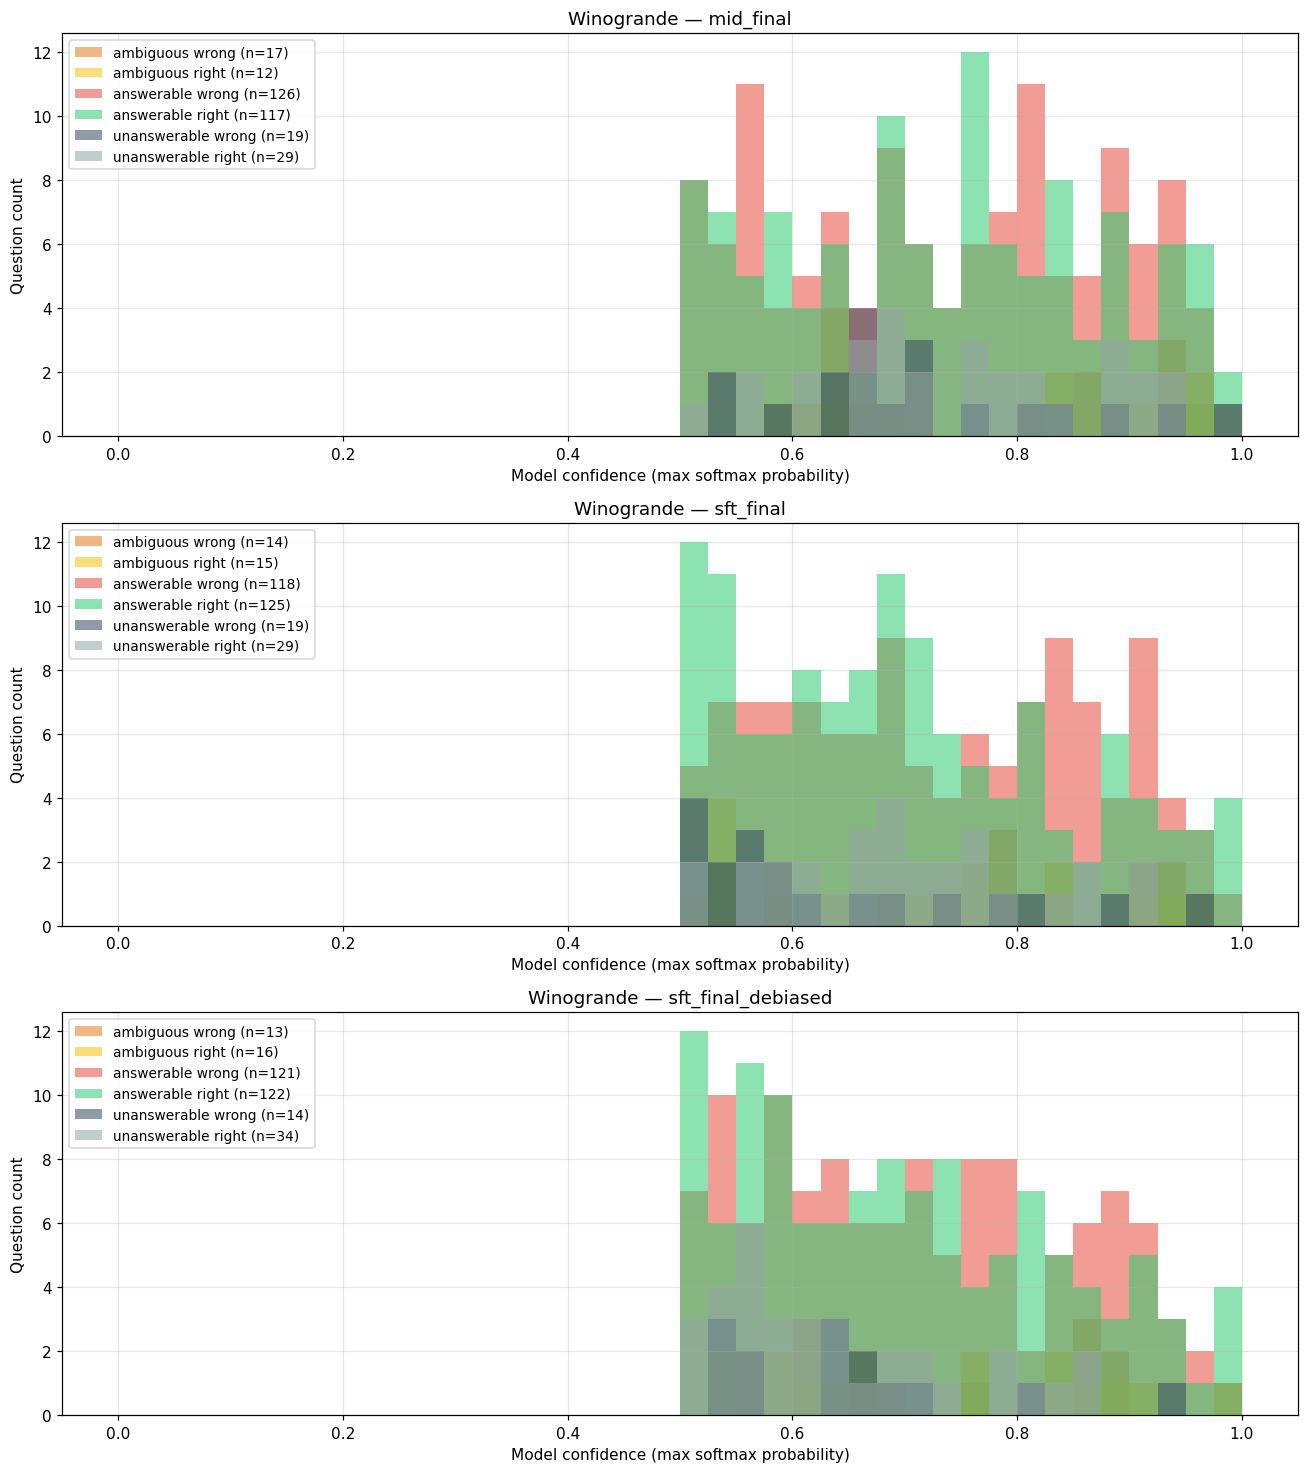

In [5]:
fig, axes = plt.subplots(len([s for s in STAGES if not dfs[s].empty]), 1, figsize=(12, 4.5*len([s for s in STAGES if not dfs[s].empty])))
axes = [axes] if not hasattr(axes, '__iter__') else axes
ax_iter = iter(axes)
for stage in STAGES:
    if dfs[stage].empty: continue
    ax = next(ax_iter)
    plot_confidence_histogram(dfs[stage], classes, title=f'{BENCHMARK} — {stage}', ax=ax)
plt.tight_layout()
plt.show()

## 5. High-Confidence Wrong Answers (answerable subset, Mid phase)

The diagnostic gold. These are questions the model should be able to answer using 1900-1949 knowledge, but got confidently wrong. Review these to identify patterns.

In [6]:
wrong = high_confidence_wrong(dfs['mid_final'], classes, label_filter='answerable', n=20, min_conf=0.5)
print(f'{len(wrong)} high-confidence wrong answers on the answerable subset\n')

for i, (_, row) in enumerate(wrong.iterrows(), 1):
    parsed = extract_stem_and_choices(row['question'])
    print(f'[{i:02d}] conf={row["confidence"]:.0%} pred={row["predicted"]} expected={row["expected"]}')
    print(f'     Q: {parsed["stem"][:280]}')
    for L in sorted(parsed['choices'].keys()):
        mark = ' ← PREDICTED' if L == row['predicted'] else (' ← CORRECT' if L == row['expected'] else '')
        print(f'       {L}: {parsed["choices"][L][:160]}{mark}')
    print()

20 high-confidence wrong answers on the answerable subset

[01] conf=98% pred=A expected=B
     Q: Fill in the blank: At the beauty salon, Angela preferred to work on her eyebrows instead of her eyelashes because the _ were already worked on.
       A: eyebrows ← PREDICTED
       B: eyelashes ← CORRECT

[02] conf=97% pred=A expected=B
     Q: Fill in the blank: Kayla was always thinner than Rachel because _ enjoyed eating brioche and butter every morning.
       A: Kayla ← PREDICTED
       B: Rachel ← CORRECT

[03] conf=97% pred=A expected=B
     Q: Fill in the blank: I don't want to use that iron on my new shirt, and, yes, it's because the _ is too expensive.
       A: iron ← PREDICTED
       B: shirt ← CORRECT

[04] conf=97% pred=A expected=B
     Q: Fill in the blank: Michael just bought brand new wheels for his truck unlike Leslie because _ wheels were new and perfect.
       A: Michael ← PREDICTED
       B: Leslie ← CORRECT

[05] conf=96% pred=A expected=B
     Q: Fill in the blan

## 6. Mid vs SFT on Answerable Subset

Did SFT help on the answerable slice, or did it just overfit to internal distribution?

In [7]:
if not dfs['sft_final'].empty:
    mid_trip = accuracy_triple(dfs['mid_final'], classes)
    sft_trip = accuracy_triple(dfs['sft_final'], classes)
    deb_trip = accuracy_triple(dfs['sft_final_debiased'], classes) if not dfs['sft_final_debiased'].empty else None
    rows = []
    for bucket in ['overall','answerable','unanswerable']:
        m = mid_trip.get(bucket,{}).get('acc')
        s = sft_trip.get(bucket,{}).get('acc')
        d = (deb_trip.get(bucket,{}).get('acc') if deb_trip else None)
        if m is None or s is None: continue
        rows.append({
            'bucket': bucket, 'n': mid_trip[bucket]['n'],
            'Mid_%': round(100*m,1), 'SFT_%': round(100*s,1),
            'Debiased_%': round(100*d,1) if d is not None else None,
            'SFT-Mid_delta': round(100*(s-m),1),
        })
    pd.DataFrame(rows)

## 7. Error-Type Clustering

What kinds of questions (within the answerable subset) does the model miss most?

In [8]:
# Winogrande: cluster by commonsense anchor (heuristic)
import re
ANCHORS = {
    'physical_property_attribute': r'\b(too (big|small|heavy|light|hot|cold|hard|soft|fast|slow|long|short|tall|wide|narrow|thick|thin))\b',
    'role_profession': r'\b(doctor|teacher|student|lawyer|judge|farmer|miller|chef|cook|mechanic|nurse|builder|carpenter|engineer|manager|officer|clerk)\b',
    'motivation_feeling': r'\b(wanted|needed|hoped|feared|loved|hated|thought|believed|worried|because _ was feeling)\b',
    'possession_ownership': r'\b(_ had|_ owned|_ brought|_ kept|_.s)\b',
}

wrong_df = dfs['mid_final'][dfs['mid_final']['correct'] == False].copy()
wrong_df['qhash'] = wrong_df['question'].map(_hash_question)
wrong_df['label'] = wrong_df['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
ans_wrong = wrong_df[wrong_df['label']=='answerable']

for anchor, pat in ANCHORS.items():
    hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]
    print(f'{anchor}: {len(hits)} answerable wrong (of {len(ans_wrong)})')
    if len(hits):
        sample = hits.iloc[0]
        parsed = extract_stem_and_choices(sample['question'])
        print(f'  example: {parsed["stem"][:180]}')
    print()

physical_property_attribute: 4 answerable wrong (of 126)
  example: Fill in the blank: We were making orange jack o lanterns and  bought candles to put in the oranges, the candles did not fit. The _ were too small.

role_profession: 1 answerable wrong (of 126)
  example: Fill in the blank: The school needed a new auditorium and a new teacher's lounge.  They built the _ first because it benefited the faculty more.

motivation_feeling: 19 answerable wrong (of 126)
  example: Fill in the blank: To make frosting I needed pudding that was at a store 15 minutes away but pre-made frosting was at a store 5 minutes away.  The _ was closer.

possession_ownership: 12 answerable wrong (of 126)
  example: Fill in the blank: Playing basketball came easier for Cynthia than Jennifer but _ had more control of their body movements.



C:\Users\danielyoon\AppData\Local\Temp\ipykernel_31084\3360423127.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]


## 8. Verdict

Interpretation based on the answerable-subset accuracy:

- **answerable_acc > random + 15pp**: Real skill transfer. Model has the capability.
- **answerable_acc within ±5pp of random**: Skill gap. The model can't reason about even period-compatible content.
- **answerable_acc >> overall_acc**: Content gap dominates. Targeted synthetic data on modern vocabulary could help.
- **high-conf wrong clusters around one error type**: Targeted fix possible — rewrite the corresponding generator.

In [9]:
# Verdict computation
trip = accuracy_triple(dfs['mid_final'], classes)
overall = trip.get('overall', {}).get('acc', 0) or 0
answerable = trip.get('answerable', {}).get('acc', 0) or 0
unanswerable = trip.get('unanswerable', {}).get('acc', 0) or 0

verdict = []
if answerable > RANDOM_BASELINE + 0.15:
    verdict.append(f'✅ Real skill transfer: answerable={100*answerable:.1f}% vs random={100*RANDOM_BASELINE:.0f}%')
elif abs(answerable - RANDOM_BASELINE) < 0.05:
    verdict.append(f'⚠️ Skill gap: answerable subset at {100*answerable:.1f}% (near random).')
else:
    verdict.append(f'➖ Modest transfer: answerable={100*answerable:.1f}%, +{100*(answerable-RANDOM_BASELINE):.1f}pp vs random.')

if answerable - overall > 0.05:
    verdict.append(f'📈 Content gap contributes: answerable ({100*answerable:.1f}%) beats overall ({100*overall:.1f}%) by {100*(answerable-overall):.1f}pp.')

if unanswerable > RANDOM_BASELINE + 0.05:
    verdict.append(f'⚠️ Unanswerable subset at {100*unanswerable:.1f}% — model may be leaking modern knowledge.')

print('\n'.join(verdict))

⚠️ Skill gap: answerable subset at 48.1% (near random).
⚠️ Unanswerable subset at 60.4% — model may be leaking modern knowledge.
